# Encoder input, T = 64: cropped links, every window padded to 64, with a mask

This notebook turns the prepared files in `src/data/prepared_data/` (written by
`src/pipeline/input_representation.ipynb`) into the input the encoder reads: windows of **at most 64 messages ×
13 features**, each with a mask.

**Which data.** Only the two GridSybil scenario folders, `GridSybil_0709` and `GridSybil_1416`. Their senders
are exactly benign cars (code 0) and GridSybil attackers (code 16). The other scenario folders replay the
same traffic, so their benign senders are near-copies of the ones here and would add duplicates, not new
information. Links whose sender has an unknown label (code -1) are dropped and counted.

**Crop.** A *link* is everything one receiving car heard from one sender pseudonym, in time order. Each link
is cut into consecutive, **non-overlapping** pieces of at most 64 messages: a link of 150 messages gives
64 + 64 + 22. Every message lands in exactly one window and nothing is thrown away.

**One fixed length.** Every piece is padded at the end with zero rows up to **64**: the 22-message piece above
becomes 64 rows (22 real + 42 padding). Every window has the same shape, 64 × 13, so the encoder always sees
T = 64. The price is compute: about 71% of all stored rows are padding, because most links are short.
(`buckets = (64,)`; setting `(8, 16, 32, 64)` instead pads only to the smallest size that fits.)

**Mask.** Padding rows are zeros, and the encoder's FFT and convolutions would read them as data. The
**mask** (1 = real message, 0 = padding) tells the encoder which rows are real, so they can be ignored in
pooling and losses. With 71% padding this matters even more: without the mask, most of what the encoder sees
would be zeros. The mask must never be fed to a classifier as a feature: the amount of padding differs
between classes and would be a shortcut.

**Very short windows.** A window of 1–3 messages gives TimesNet's FFT almost nothing to work with. They are
kept here (`min_messages = 1`) and counted below; a floor such as 4 is an option.

**Labels and split.** A window takes the label of its **sender** (0 benign / 16 GridSybil, plus a binary
`is_attack`) and the split of its sender vehicle, looked up as `"<group>:<sender>"` in the vehicle-grouped
split stored in `index.json` (the same car never appears in two splits, RULE 3).

**One missing value.** The first message of a link has no previous message, so its `log_dtau` is missing
(`null` in the prepared file, `NaN` here). After normalisation it becomes 0, which is the train mean, so it
carries no information.

This first half builds the windows in memory (`windows`); the second half normalises them and writes JSON.

In [1]:
from __future__ import annotations

import dataclasses
import json
import multiprocessing
import os
import pathlib
import time
from typing import Any

import numpy as np
import pandas as pd

# Run from the repository root, so that every relative path resolves the same way every time.
for _folder in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:  # notebooks live in src/<folder>/; work from the repo root
    if (_folder / "CLAUDE.md").is_file():
        os.chdir(_folder)
        break
assert pathlib.Path("CLAUDE.md").is_file() and pathlib.Path("data").is_dir(), (
    f"run this notebook from the repository root (now in {pathlib.Path.cwd()})")
print("working directory:", pathlib.Path.cwd())

working directory: /Users/bibekgupta/Downloads/projects/sybil-llm


## Settings

Everything that can change lives in one frozen dataclass; the second half stores it next to the output.

In [2]:
@dataclasses.dataclass(frozen=True)
class EncoderInputSettings:
    """Settings for building fixed-length encoder windows.

    Attributes:
        prepared_dir: Folder of prepared files plus `index.json` (read only here).
        out_dir: Where the sharded JSON output goes (gitignored).
        seq_len: Maximum messages per window (T).
        crop_stride: Messages between the starts of two crops of a link; equal to `seq_len` means no overlap.
        buckets: Allowed window lengths; a window is padded up to the smallest bucket that fits it.
        min_messages: Windows with fewer real messages are dropped and counted (1 keeps every window).
        scenarios: Scenario folders to read.
        keep_codes: Sender attack codes to keep (0 benign, 16 GridSybil).
        shard_size: Windows per output shard.
        decimals: Decimals kept for every float written to disk.
        workers: Number of worker processes for reading.
        allowed_out_root: The only folder the writer may write into.
    """

    prepared_dir: str = "src/data/prepared_data"
    out_dir: str = "src/data/encoder_input/benign_gridsybil/T64"
    seq_len: int = 64
    crop_stride: int = 64
    buckets: tuple[int, ...] = (64,)
    min_messages: int = 1
    scenarios: tuple[str, ...] = ("GridSybil_0709", "GridSybil_1416")
    keep_codes: tuple[int, ...] = (0, 16)
    shard_size: int = 10000
    decimals: int = 4
    workers: int = 10
    allowed_out_root: str = "src/data/encoder_input"

    def __post_init__(self) -> None:
        if self.seq_len < 1:
            raise ValueError(f"seq_len must be >= 1, got {self.seq_len}")
        if not 1 <= self.crop_stride <= self.seq_len:
            raise ValueError(f"crop_stride must be in [1, seq_len], got {self.crop_stride}")
        if list(self.buckets) != sorted(set(self.buckets)) or self.buckets[-1] != self.seq_len:
            raise ValueError(f"buckets must be increasing and end at seq_len, got {self.buckets}")
        if not 1 <= self.min_messages <= self.seq_len:
            raise ValueError(f"min_messages must be in [1, seq_len], got {self.min_messages}")
        if self.workers < 1:
            raise ValueError(f"workers must be >= 1, got {self.workers}")
        if self.shard_size < 1:
            raise ValueError(f"shard_size must be >= 1, got {self.shard_size}")
        if pathlib.Path(self.out_dir).resolve().is_relative_to(pathlib.Path("data").resolve()):
            raise ValueError("out_dir must not be inside data/ (read-only, RULE 2)")


SETTINGS = EncoderInputSettings()

FEATURE_NAMES: tuple[str, ...] = (
    "claimed_pos_x", "claimed_pos_y",
    "rx_pos_x", "rx_pos_y",
    "claimed_vel_x", "claimed_vel_y",
    "rx_vel_x", "rx_vel_y",
    "claimed_acl_x", "claimed_acl_y",
    "range", "bearing",
    "log_dtau",
)
N_FEATURES = len(FEATURE_NAMES)
LOG_DTAU_COL = FEATURE_NAMES.index("log_dtau")
print(SETTINGS)

EncoderInputSettings(prepared_dir='src/data/prepared_data', out_dir='src/data/encoder_input/benign_gridsybil/T64', seq_len=64, crop_stride=64, buckets=(64,), min_messages=1, scenarios=('GridSybil_0709', 'GridSybil_1416'), keep_codes=(0, 16), shard_size=10000, decimals=4, workers=10, allowed_out_root='src/data/encoder_input')


## Labels and split from `index.json`

`index.json` holds the attack code of every sender vehicle per scenario folder and the vehicle-grouped split.
`IndexBook` answers two questions for a sender: *what is its label?* and *which split is it in?*

In [3]:
class IndexBook:
    """Sender labels and the vehicle-grouped split, read from `index.json`.

    Attributes:
        labels: Scenario folder -> {vehicle id -> attack code}.
        class_names: Attack code -> class name.
        split_of_vehicle: `"<group>:<vehicle>"` -> split name.
        source: Path and provenance of the index file.
    """

    def __init__(self, index_path: pathlib.Path) -> None:
        """Loads the index.

        Args:
            index_path: Path to `index.json`.
        """
        index = json.loads(index_path.read_text())
        if list(index["features"]) != list(FEATURE_NAMES):
            raise ValueError(f"feature order in {index_path} differs from FEATURE_NAMES")
        self.labels: dict[str, dict[int, int]] = {
            scenario: {int(vehicle): int(code) for vehicle, code in codes.items()}
            for scenario, codes in index["labels"].items()}
        self.class_names: dict[int, str] = {int(code): name for code, name in index["class_names"].items()}
        self.split_of_vehicle: dict[str, str] = {}
        for split, keys in index["split"]["vehicles"].items():
            for key in keys:
                if key in self.split_of_vehicle:
                    raise ValueError(f"vehicle {key} is in two splits")  # RULE 3
                self.split_of_vehicle[key] = split
        self.split_names: tuple[str, ...] = tuple(index["split"]["vehicles"])
        self.source = {"path": str(index_path), "provenance": index.get("provenance", {})}

    def label(self, scenario: str, sender: int) -> int:
        """Returns the sender's attack code, or -1 if it is not known."""
        return self.labels.get(scenario, {}).get(sender, -1)

    def split(self, scenario: str, sender: int) -> str | None:
        """Returns the sender vehicle's split, or None if the vehicle is not in the split."""
        return self.split_of_vehicle.get(f"{group_of(scenario)}:{sender}")


def group_of(scenario: str) -> str:
    """Returns the time-window group of a scenario folder, e.g. 'GridSybil_0709' -> '0709'."""
    return scenario.rsplit("_", 1)[1]


INDEX = IndexBook(pathlib.Path(SETTINGS.prepared_dir) / "index.json")
print("splits:", INDEX.split_names, "| vehicles in split:", len(INDEX.split_of_vehicle))
print("class names:", INDEX.class_names)

splits: ('train', 'pretrain_val', 'val', 'test') | vehicles in split: 7508
class names: {-1: 'Unknown', 0: 'Benign', 16: 'GridSybil', 17: 'DataReplaySybil', 18: 'DoSRandomSybil', 19: 'DoSDisruptiveSybil'}


## Reading the prepared files

There is one prepared file per receiving car. Reading them is the slow part, so it runs in parallel worker
processes. The worker function sits at the top level of the notebook so worker processes can find it
(`fork` start method). Each worker returns the links of one file with their 13-feature rows as a float32
array; the missing first `log_dtau` becomes `NaN`.

In [4]:
def read_prepared_file(path_str: str) -> dict[str, Any]:
    """Reads one prepared receiver file (worker function, must stay top level).

    Args:
        path_str: Path of the prepared JSON file.

    Returns:
        The receiver, its run, and a list of links, each with `sender`, `sender_pseudo` and `x`
        (float32 array of shape (messages, 13), missing values as NaN).
    """
    record = json.loads(pathlib.Path(path_str).read_text())
    links = []
    for link in record["links"]:
        x = np.array(link["x"], dtype=np.float32).reshape(-1, N_FEATURES)  # JSON null -> NaN
        links.append({"sender": int(link["sender"]), "sender_pseudo": int(link["sender_pseudo"]), "x": x})
    return {"path": path_str, "receiver": int(record["receiver"]), "run": record["run"], "links": links}


class PreparedReader:
    """Reads every prepared receiver file of the chosen scenario folders in parallel."""

    def __init__(self, settings: EncoderInputSettings) -> None:
        """Stores the settings.

        Args:
            settings: The notebook settings.
        """
        self.settings = settings
        self.root = pathlib.Path(settings.prepared_dir)

    def files(self) -> list[pathlib.Path]:
        """Lists the prepared files, sorted so the window order is reproducible."""
        found: list[pathlib.Path] = []
        for scenario in self.settings.scenarios:
            folder = self.root / scenario
            if not folder.is_dir():
                raise FileNotFoundError(f"missing scenario folder {folder}")
            found.extend(sorted(folder.glob("*/traceJSON-*.json")))
        return found

    def read(self) -> list[dict[str, Any]]:
        """Reads all files; results come back in the same order as `files()`."""
        paths = [str(path) for path in self.files()]
        context = multiprocessing.get_context("fork")
        with context.Pool(self.settings.workers) as pool:
            return pool.map(read_prepared_file, paths, chunksize=16)

## Cropping links into 64-row windows

`LinkWindower` crops each link into non-overlapping pieces of at most 64 messages (a link of `n` messages gives
`ceil(n / 64)` windows). Every window sits in a 64-row array: its real rows first, then zero rows; `mask` is 1
on the real rows. (The `bucket` column is always 64 here; with several buckets the second half would cut each
window to its bucket size.) The windower first counts all windows,
then fills pre-allocated arrays, so memory stays at one copy.

In [5]:
def crop_starts(n_messages: int, max_len: int, stride: int) -> list[int]:
    """Returns the start of every crop of a link, stopping at the first crop that reaches the link's end.

    Args:
        n_messages: Messages in the link.
        max_len: Maximum messages per crop (T).
        stride: Messages between two crop starts (`max_len` = no overlap).

    Returns:
        Start offsets; with `stride == max_len` every message is in exactly one crop.
    """
    starts = [0]
    while starts[-1] + max_len < n_messages:
        starts.append(starts[-1] + stride)
    return starts


def bucket_of(n_messages: int, buckets: tuple[int, ...]) -> int:
    """Returns the smallest bucket that holds `n_messages` rows."""
    for size in buckets:
        if n_messages <= size:
            return size
    raise ValueError(f"{n_messages} messages do not fit the largest bucket {buckets[-1]}")


@dataclasses.dataclass
class Windows:
    """Cropped, bucketed windows held in memory.

    Attributes:
        x_raw: float32 (N, T, 13); real rows hold raw values, rows beyond `n_messages` are 0,
            the missing first log_dtau of a link is NaN.
        mask: uint8 (N, T); 1 for the first `n_messages` rows (real), 0 for padding.
        meta: One row per window (ids, provenance, n_messages, bucket, label, split).
        counts: Links kept / dropped, messages, windows per split and class.
    """

    x_raw: np.ndarray
    mask: np.ndarray
    meta: pd.DataFrame
    counts: dict[str, Any]


class LinkWindower:
    """Turns prepared files into labelled, split, cropped and bucketed windows."""

    def __init__(self, settings: EncoderInputSettings, index: IndexBook) -> None:
        """Stores collaborators.

        Args:
            settings: The notebook settings.
            index: Labels and split lookup.
        """
        self.settings = settings
        self.index = index

    def build(self, files: list[dict[str, Any]]) -> Windows:
        """Selects the kept links, crops them, and assigns each window a bucket and a mask.

        Args:
            files: Output of `PreparedReader.read()`.

        Returns:
            The windows with their mask, meta table and counts.
        """
        s = self.settings
        t = s.seq_len
        kept, drops = self._select(files)
        pieces = [(i, start, min(len(link["x"]) - start, t))
                  for i, (_, link, _, _) in enumerate(kept)
                  for start in crop_starts(len(link["x"]), t, s.crop_stride)]
        short = [p for p in pieces if p[2] < s.min_messages]
        pieces = [p for p in pieces if p[2] >= s.min_messages]
        x_raw = np.zeros((len(pieces), t, N_FEATURES), dtype=np.float32)
        mask = np.zeros((len(pieces), t), dtype=np.uint8)
        rows: list[dict[str, Any]] = []
        link_k: dict[int, int] = {}
        for w, (i, start, n) in enumerate(pieces):
            record, link, code, split = kept[i]
            k = link_k[i] = link_k.get(i, -1) + 1
            x_raw[w, :n] = link["x"][start:start + n]
            mask[w, :n] = 1
            receiver_file = str(pathlib.Path(record["path"]).relative_to(s.prepared_dir))
            rows.append({
                "window_id": f"{receiver_file}#{link['sender_pseudo']}-{link['sender']}#{k}",
                "scenario": record["run"].split("/", 1)[0], "run": record["run"], "receiver_file": receiver_file,
                "receiver": record["receiver"], "sender": link["sender"], "sender_pseudo": link["sender_pseudo"],
                "link_window_index": k, "n_messages": n, "bucket": bucket_of(n, s.buckets),
                "label": code, "label_name": self.index.class_names.get(code, str(code)),
                "is_attack": int(code != 0), "split": split})
        meta = pd.DataFrame(rows)
        if not meta["window_id"].is_unique:
            raise ValueError("window ids are not unique")
        drops["below_min_messages"] = {"windows": len(short), "messages": int(sum(p[2] for p in short))}
        return Windows(x_raw=x_raw, mask=mask, meta=meta, counts=self._counts(kept, drops, meta))

    def _select(self, files: list[dict[str, Any]]) -> tuple[list[tuple], dict[str, dict[str, int]]]:
        """Keeps links whose sender code is wanted and whose sender vehicle has a split."""
        kept: list[tuple] = []
        drops = {reason: {"links": 0, "messages": 0}
                 for reason in ("unknown_label", "other_code", "no_split", "empty")}
        for record in files:
            scenario = record["run"].split("/", 1)[0]
            for link in record["links"]:
                code = self.index.label(scenario, link["sender"])
                split = self.index.split(scenario, link["sender"])
                if len(link["x"]) == 0:
                    reason = "empty"
                elif code == -1:
                    reason = "unknown_label"
                elif code not in self.settings.keep_codes:
                    reason = "other_code"
                elif split is None:
                    reason = "no_split"
                else:
                    kept.append((record, link, code, split))
                    continue
                drops[reason]["links"] += 1
                drops[reason]["messages"] += len(link["x"])
        return kept, drops

    def _counts(self, kept: list[tuple], drops: dict[str, dict[str, int]], meta: pd.DataFrame) -> dict[str, Any]:
        """Summarises what was kept and dropped, per split × bucket × class."""
        per = meta.groupby(["split", "bucket", "label_name"]).agg(
            windows=("n_messages", "size"), messages=("n_messages", "sum"), rows=("bucket", "sum"))
        per["padding_share"] = 1.0 - per["messages"] / per["rows"]
        return {
            "files": len({record["path"] for record, *_ in kept}),
            "links_kept": len(kept),
            "messages_kept": int(sum(len(link["x"]) for _, link, _, _ in kept)),
            "messages_in_windows": int(meta["n_messages"].sum()) if len(meta) else 0,
            "dropped": drops,
            "windows": int(len(meta)),
            "per_split_bucket_class": {
                f"{split}/b{bucket:02d}/{name}": {
                    "windows": int(row["windows"]), "messages": int(row["messages"]),
                    "padding_share": round(float(row["padding_share"]), 4)}
                for (split, bucket, name), row in per.iterrows()},
        }

## Build the windows

In [6]:
_start = time.perf_counter()
_files = PreparedReader(SETTINGS).read()
print(f"read {len(_files)} prepared files in {time.perf_counter() - _start:.1f} s")
windows = LinkWindower(SETTINGS, INDEX).build(_files)
del _files
print(f"built {len(windows.meta):,} windows in {time.perf_counter() - _start:.1f} s total "
      f"(x_raw {windows.x_raw.nbytes / 1e9:.2f} GB)")
print(json.dumps({k: v for k, v in windows.counts.items() if k != "per_split_bucket_class"}, indent=1))

read 5755 prepared files in 1.7 s
built 376,427 windows in 9.5 s total (x_raw 1.25 GB)
{
 "files": 5752,
 "links_kept": 354197,
 "messages_kept": 6980356,
 "messages_in_windows": 6980356,
 "dropped": {
  "unknown_label": {
   "links": 271,
   "messages": 4123
  },
  "other_code": {
   "links": 0,
   "messages": 0
  },
  "no_split": {
   "links": 0,
   "messages": 0
  },
  "empty": {
   "links": 0,
   "messages": 0
  },
  "below_min_messages": {
   "windows": 0,
   "messages": 0
  }
 },
 "windows": 376427
}


## Windows per split, bucket and class

How many windows each split holds in each bucket, for benign and GridSybil senders. Every shard on disk holds
one split and one bucket, so these are also the shard groups.

In [7]:
class BucketReport:
    """Summaries of the bucketed windows: counts, padding, and very short windows."""

    def __init__(self, windows: Windows, settings: EncoderInputSettings) -> None:
        """Stores the window table.

        Args:
            windows: The built windows.
            settings: The notebook settings.
        """
        self.meta = windows.meta
        self.settings = settings

    def by_split_bucket_class(self) -> pd.DataFrame:
        """Windows per split × bucket (rows) and class (columns), with totals."""
        table = self.meta.groupby(["split", "bucket", "label_name"]).size().unstack(fill_value=0)
        table["total"] = table.sum(axis=1)
        return table

    def padding(self) -> pd.DataFrame:
        """Padding share per bucket and overall: padding rows / all stored rows."""
        per = self.meta.groupby("bucket").agg(windows=("n_messages", "size"), real_rows=("n_messages", "sum"),
                                              stored_rows=("bucket", "sum"))
        per.loc["overall"] = per.sum()
        per["padding_share"] = (1.0 - per["real_rows"] / per["stored_rows"]).round(3)
        return per

    def padding_if_all_max(self) -> float:
        """Padding share if every window were padded to the maximum length T."""
        return 1.0 - self.meta["n_messages"].sum() / (len(self.meta) * self.settings.seq_len)

    def very_short(self, below: int = 4) -> pd.DataFrame:
        """Windows with fewer than `below` messages, per class (count and share of the class)."""
        short = self.meta["n_messages"] < below
        return self.meta.assign(short=short).groupby("label_name")["short"].agg(
            windows="size", short_windows="sum", share="mean").round(3)


REPORT = BucketReport(windows, SETTINGS)
_table = REPORT.by_split_bucket_class()
print(_table.to_string())
_split_totals = windows.meta.groupby("split").size()
print("\nwindows per split:", _split_totals.to_dict())
print("benign share:", round(float((windows.meta["is_attack"] == 0).mean()), 3))

label_name           Benign  GridSybil   total
split        bucket                           
pretrain_val 64        8517      19889   28406
test         64       20045      33923   53968
train        64       84282     152150  236432
val          64       19970      37651   57621

windows per split: {'pretrain_val': 28406, 'test': 53968, 'train': 236432, 'val': 57621}
benign share: 0.353


## Padding

Padding share = padding rows / all stored rows. With every window padded to 64 this is the price of the fixed
length.

In [8]:
_padding = REPORT.padding()
print(_padding.to_string())
print(f"\noverall padding with buckets {SETTINGS.buckets}: {_padding.loc['overall', 'padding_share']:.1%} "
      f"vs {REPORT.padding_if_all_max():.1%} if every window were padded to {SETTINGS.seq_len}")

         windows  real_rows  stored_rows  padding_share
bucket                                                 
64        376427    6980356     24091328           0.71
overall   376427    6980356     24091328           0.71

overall padding with buckets (64,): 71.0% vs 71.0% if every window were padded to 64


## Very short windows (1–3 messages)

These give TimesNet's FFT almost nothing. They are kept (`min_messages = 1`); if the share differs a lot
between classes, window length alone could hint at the class, which is worth remembering at evaluation time.

In [9]:
print(REPORT.very_short(below=4).to_string())

            windows  short_windows  share
label_name                               
Benign       132814          18509  0.139
GridSybil    243613          49242  0.202


## Windows per class

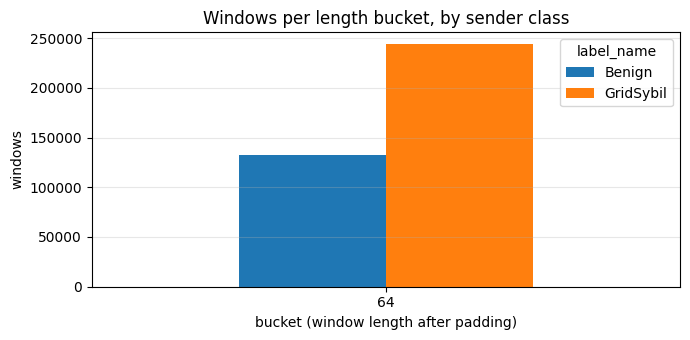

bucket with the most windows per class: {'Benign': 64, 'GridSybil': 64}


In [10]:
import matplotlib.pyplot as plt

_counts = windows.meta.pivot_table(index="bucket", columns="label_name", values="n_messages",
                                   aggfunc="size", fill_value=0)
_fig, _ax = plt.subplots(figsize=(7, 3.5))
_counts.plot.bar(ax=_ax, rot=0)
_ax.set_xlabel("bucket (window length after padding)")
_ax.set_ylabel("windows")
_ax.set_title("Windows per length bucket, by sender class")
_ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
_largest = _counts.idxmax().to_dict()
print("bucket with the most windows per class:", _largest)

## Normalise with statistics from the train windows only

Every feature is scaled to mean 0 and standard deviation 1. The mean and standard deviation come from the
**real rows of the train windows** only (mask = 1). Padding rows and the missing `log_dtau` of the first
message of each link are ignored.

After scaling:
- real rows hold the normalised values;
- the missing `log_dtau` becomes **0**, which is exactly the train mean (the most neutral value we can give);
- padding rows are **0** in every feature, and the mask marks them (1 = real message, 0 = padding).

The same train statistics are applied to every split, so nothing from val / test leaks into the scaling.

In [11]:
import json
import platform
import shutil
import subprocess
from dataclasses import asdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn


class TrainNormaliser:
    """Per-feature mean / std fitted on the real rows of the train windows.

    Attributes:
        features: Feature names, in column order.
        mean: Per-feature mean, shape (n_features,).
        std: Per-feature standard deviation, shape (n_features,); a constant feature gets 1.0.
        n_values: Per-feature number of values the statistics were computed from.
    """

    def __init__(self, features: list[str]) -> None:
        self.features = list(features)
        self.mean: np.ndarray | None = None
        self.std: np.ndarray | None = None
        self.n_values: np.ndarray | None = None

    def fit(self, x_raw: np.ndarray, mask: np.ndarray, rows: np.ndarray) -> "TrainNormaliser":
        """Computes the statistics from the real rows of the selected windows.

        Args:
            x_raw: Raw values, shape (N, T, F); padding rows are 0, a missing log_dtau is NaN.
            mask: 1 = real row, 0 = padding, shape (N, T).
            rows: Boolean selector of the windows to fit on (the train windows), shape (N,).

        Returns:
            self, fitted.
        """
        picked = np.flatnonzero(rows)
        real = x_raw[picked][mask[picked].astype(bool)].astype(np.float64)  # (n_real_rows, F)
        if real.shape[0] == 0:
            raise ValueError("No real rows in the train windows; cannot fit the normaliser.")
        self.n_values = np.sum(~np.isnan(real), axis=0)
        self.mean = np.nanmean(real, axis=0)
        std = np.nanstd(real, axis=0)
        self.std = np.where(std > 0, std, 1.0)
        return self

    def apply(self, x_raw: np.ndarray, mask: np.ndarray, chunk: int = 50_000) -> np.ndarray:
        """Normalises every window; missing values and padding rows become 0.

        Args:
            x_raw: Raw values, shape (N, T, F).
            mask: 1 = real row, 0 = padding, shape (N, T).
            chunk: Windows processed at a time (keeps memory low on the full data).

        Returns:
            Normalised float32 array, shape (N, T, F).
        """
        if self.mean is None:
            raise RuntimeError("Call fit() before apply().")
        out = np.empty(x_raw.shape, dtype=np.float32)
        for start in range(0, len(x_raw), chunk):
            part = (x_raw[start:start + chunk].astype(np.float64) - self.mean) / self.std
            part = np.nan_to_num(part, nan=0.0)               # missing log_dtau -> train mean -> 0
            part[mask[start:start + chunk] == 0] = 0.0       # padding rows -> 0 in every feature
            out[start:start + chunk] = part
        return out

    def to_dict(self) -> dict:
        """Returns the statistics as plain JSON-ready values."""
        return {
            "features": self.features,
            "mean": [float(v) for v in self.mean],
            "std": [float(v) for v in self.std],
            "n_values": [int(v) for v in self.n_values],
            "fitted_on": "train windows, real rows only (mask = 1; padding and missing log_dtau ignored)",
            "missing_log_dtau": "first message of each link has no previous message; set to 0 (= train mean)",
            "padding": "padding rows are 0 in every feature; mask = 0 marks them",
        }


def check_only_log_dtau_missing(x_raw: np.ndarray, mask: np.ndarray, features: list[str]) -> None:
    """Fails if a real row has a missing value in any feature other than log_dtau."""
    missing = np.isnan(x_raw[mask.astype(bool)]).sum(axis=0)
    others = {f: int(n) for f, n in zip(features, missing) if n and f != "log_dtau"}
    assert not others, f"Unexpected missing values in real rows: {others}"

In [12]:
features = json.loads((Path(SETTINGS.prepared_dir) / "index.json").read_text())["features"]
MAX_LEN = SETTINGS.seq_len
BUCKETS = tuple(SETTINGS.buckets)
assert windows.x_raw.shape[1:] == (MAX_LEN, len(features)), windows.x_raw.shape
assert windows.mask.shape == windows.x_raw.shape[:2], windows.mask.shape
check_only_log_dtau_missing(windows.x_raw, windows.mask, features)

is_train = (windows.meta["split"] == "train").to_numpy()
normaliser = TrainNormaliser(features).fit(windows.x_raw, windows.mask, is_train)
x_norm = normaliser.apply(windows.x_raw, windows.mask)

pd.DataFrame(
    {"mean": normaliser.mean, "std": normaliser.std, "n_values": normaliser.n_values}, index=features
).round(4)

,mean,std,n_values
claimed_pos_x,487.4356,462.5555,4378988
claimed_pos_y,644.8299,387.0039,4378988
rx_pos_x,484.2348,394.4511,4378988
rx_pos_y,645.4262,303.4572,4378988
claimed_vel_x,-0.0308,5.0794,4378988
claimed_vel_y,0.0893,5.8947,4378988
rx_vel_x,0.0017,7.1294,4378988
rx_vel_y,0.2343,8.1629,4378988
claimed_acl_x,0.0005,0.9619,4378988
claimed_acl_y,-0.0090,1.2548,4378988


## Write the encoder input as JSON shards, one folder per split

Every window is 64 rows, so each split has one folder, `<split>/b64/`. Every shard holds windows of one split.
- `part-XXXXX.json` holds only what the encoder reads: the window `id`, `x` (bucket × 13, normalised,
  4 decimals) and `mask` (bucket values, 1 = real message, 0 = padding). **No labels and no vehicle ids.**
- `part-XXXXX_info.json` holds the bookkeeping for the same windows, in the same order: scenario, run,
  receiver file, receiver, sender, sender pseudonym, window index within the link, number of messages,
  bucket, label, label name and `is_attack`.

The writer refuses to write anywhere except under the allowed folder (`src/data/encoder_input`), and clears
an existing output only when `overwrite=True`.

In [13]:
class ShardedJsonWriter:
    """Writes normalised windows as JSON shards, one folder per split and bucket.

    Attributes:
        out_dir: Output folder (resolved).
        features: Feature names, in column order.
        max_len: Maximum window length (T).
        shard_size: Windows per shard.
        decimals: Decimals kept for x.
        overwrite: Whether an existing output may be cleared.
    """

    INFO_COLUMNS = ["scenario", "run", "receiver_file", "receiver", "sender", "sender_pseudo",
                    "link_window_index", "n_messages", "bucket", "label", "label_name", "is_attack"]

    def __init__(self, out_dir: str | Path, allowed_root: str | Path, features: list[str], max_len: int,
                 shard_size: int, decimals: int, overwrite: bool = False) -> None:
        self.out_dir = Path(out_dir).resolve()
        root = Path(allowed_root).resolve()
        if not self.out_dir.is_relative_to(root):
            raise PermissionError(f"Refusing to write to {self.out_dir}: outside the allowed folder {root}.")
        self.features = list(features)
        self.max_len = max_len
        self.shard_size = shard_size
        self.decimals = decimals
        self.overwrite = overwrite

    def prepare_folder(self) -> None:
        """Creates the output folder; clears a previous output only when overwrite is set."""
        if self.out_dir.exists() and any(self.out_dir.iterdir()):
            if not self.overwrite:
                raise FileExistsError(f"{self.out_dir} is not empty; pass overwrite=True to replace it.")
            shutil.rmtree(self.out_dir)
        self.out_dir.mkdir(parents=True, exist_ok=True)

    def write_group(self, split: str, bucket: int, x: np.ndarray, mask: np.ndarray,
                    meta: pd.DataFrame) -> list[dict]:
        """Writes the windows of one split and one bucket as shards.

        Args:
            split: Split name.
            bucket: Bucket size; x and mask are cut to this many rows.
            x: Normalised windows, shape (n, T, F).
            mask: Masks, shape (n, T).
            meta: Bookkeeping rows, same order as x.

        Returns:
            One entry per shard: split, bucket, file names and number of windows.
        """
        assert (meta["bucket"] == bucket).all() and (meta["n_messages"] <= bucket).all(), (split, bucket)
        relative = f"{split}/b{bucket:02d}"
        (self.out_dir / relative).mkdir(parents=True, exist_ok=True)
        shards = []
        for number, start in enumerate(range(0, len(meta), self.shard_size)):
            stop = min(start + self.shard_size, len(meta))
            name = f"part-{number:05d}"
            rows = meta.iloc[start:stop]
            values = np.round(x[start:stop, :bucket].astype(np.float64), self.decimals) + 0.0  # -0.0 -> 0.0
            masks = mask[start:stop, :bucket].astype(int)
            data = {"seq_len": bucket, "max_seq_len": self.max_len, "features": self.features, "windows": [
                {"id": wid, "x": vals.tolist(), "mask": msk.tolist()}
                for wid, vals, msk in zip(rows["window_id"], values, masks)]}
            info = {"split": split, "bucket": bucket, "shard": name, "windows": [
                {"id": wid, **{c: self.plain(row[c]) for c in self.INFO_COLUMNS}}
                for wid, (_, row) in zip(rows["window_id"], rows.iterrows())]}
            self.dump(self.out_dir / relative / f"{name}.json", data)
            self.dump(self.out_dir / relative / f"{name}_info.json", info)
            shards.append({"split": split, "bucket": bucket, "file": f"{relative}/{name}.json",
                           "info": f"{relative}/{name}_info.json", "windows": int(stop - start),
                           "messages": int(rows["n_messages"].sum())})
        return shards

    @staticmethod
    def plain(value):
        """Turns numpy scalars into plain Python values for JSON."""
        return value.item() if isinstance(value, np.generic) else value

    @staticmethod
    def dump(path: Path, data: dict) -> None:
        """Writes compact JSON."""
        with open(path, "w") as handle:
            json.dump(data, handle, separators=(",", ":"))


SPLITS = ["train", "pretrain_val", "val", "test"]
writer = ShardedJsonWriter(SETTINGS.out_dir, SETTINGS.allowed_out_root, features, MAX_LEN,
                           SETTINGS.shard_size, SETTINGS.decimals, overwrite=True)
writer.prepare_folder()
shards = []
for split in SPLITS:
    for bucket in BUCKETS:
        picked = np.flatnonzero(((windows.meta["split"] == split) & (windows.meta["bucket"] == bucket)).to_numpy())
        if len(picked):
            shards += writer.write_group(split, bucket, x_norm[picked], windows.mask[picked],
                                         windows.meta.iloc[picked])
pd.DataFrame(shards).groupby(["split", "bucket"]).agg(shards=("file", "size"), windows=("windows", "sum"))

,,shards,windows
split,bucket,,
pretrain_val,64,3,28406
test,64,6,53968
train,64,24,236432
val,64,6,57621


## Write `metadata.json`

One file that says what is in the folder and how it was made: feature order, maximum length and buckets,
settings, the train normalisation statistics, counts per split × bucket × class (windows, messages, padding
share), the overall padding share (and what it would be if every window were padded to 64), the shard list,
where the source data came from, and the code / library versions.

Padding share = padding rows / all stored rows, where a window stores `bucket` rows.

In [14]:
class MetadataWriter:
    """Builds and writes metadata.json for the encoder input folder."""

    def __init__(self, settings, features: list[str]) -> None:
        self.settings = settings
        self.features = features

    @staticmethod
    def padding_share(messages: int, stored_rows: int) -> float:
        """Share of stored rows that are padding."""
        return round(1.0 - messages / stored_rows, 4) if stored_rows else 0.0

    def counts_by_split_bucket_class(self, meta: pd.DataFrame) -> dict:
        """Windows, messages and padding share per split, bucket and class."""
        result = {}
        for (split, bucket, name), group in meta.groupby(["split", "bucket", "label_name"]):
            messages = int(group["n_messages"].sum())
            result.setdefault(split, {}).setdefault(f"b{int(bucket):02d}", {})[name] = {
                "windows": int(len(group)),
                "messages": messages,
                "padding_share": self.padding_share(messages, int(len(group)) * int(bucket)),
            }
        return result

    def padding_overall(self, meta: pd.DataFrame) -> dict:
        """Overall and per-bucket padding share, plus the share if every window were padded to the maximum."""
        messages = int(meta["n_messages"].sum())
        per_bucket = {}
        for bucket, group in meta.groupby("bucket"):
            per_bucket[f"b{int(bucket):02d}"] = self.padding_share(int(group["n_messages"].sum()),
                                                                   int(len(group)) * int(bucket))
        return {"overall": self.padding_share(messages, int(meta["bucket"].sum())),
                "if_all_padded_to_max": self.padding_share(messages, len(meta) * self.settings.seq_len),
                "per_bucket": per_bucket,
                "windows": int(len(meta)), "messages": messages}

    def source(self) -> dict:
        """Source folder and the provenance recorded in its index.json."""
        index_path = Path(self.settings.prepared_dir) / "index.json"
        index = json.loads(index_path.read_text())
        return {"prepared_dir": str(self.settings.prepared_dir), "scenarios": list(self.settings.scenarios),
                "index_provenance": index.get("provenance", {})}

    @staticmethod
    def provenance() -> dict:
        """Git commit / dirty flag, library versions and a UTC timestamp."""
        def git(*args: str) -> str:
            try:
                return subprocess.run(["git", *args], capture_output=True, text=True, check=True).stdout.strip()
            except (OSError, subprocess.CalledProcessError):
                return ""
        return {"git_commit": git("rev-parse", "HEAD") or None, "git_dirty": bool(git("status", "--porcelain")),
                "python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
                "sklearn": sklearn.__version__, "platform": platform.platform(),
                "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds")}

    def write(self, out_dir: Path, meta: pd.DataFrame, normaliser: TrainNormaliser, shards: list[dict],
              counts: dict) -> dict:
        """Writes metadata.json and returns its content."""
        content = {
            "features": self.features,
            "max_seq_len": self.settings.seq_len,
            "buckets": [int(b) for b in self.settings.buckets],
            "layout": "<split>/b<bucket:02d>/part-XXXXX.json (+ _info.json); x and mask cut to the bucket size",
            "settings": {k: (list(v) if isinstance(v, tuple) else v) for k, v in asdict(self.settings).items()},
            "normalisation": normaliser.to_dict(),
            "counts": counts,
            "counts_by_split_bucket_class": self.counts_by_split_bucket_class(meta),
            "padding": self.padding_overall(meta),
            "shards": shards,
            "source": self.source(),
            "provenance": self.provenance(),
        }
        with open(Path(out_dir) / "metadata.json", "w") as handle:
            json.dump(content, handle, indent=1, default=ShardedJsonWriter.plain)
        return content


metadata = MetadataWriter(SETTINGS, features).write(
    writer.out_dir, windows.meta, normaliser, shards, windows.counts)
print("padding share overall:", metadata["padding"]["overall"],
      "| if all padded to 64:", metadata["padding"]["if_all_padded_to_max"])
pd.DataFrame({(s, b): {c: v["windows"] for c, v in d.items()}
              for s, by_bucket in metadata["counts_by_split_bucket_class"].items()
              for b, d in by_bucket.items()}).T.fillna(0).astype(int)

padding share overall: 0.7103 | if all padded to 64: 0.7103


,,Benign,GridSybil
pretrain_val,b64,8517,19889
test,b64,20045,33923
train,b64,84282,152150
val,b64,19970,37651


## Read back and check the written files

We re-open every shard and check:
- every `x` is bucket × 13 with no missing value, and the shard's `seq_len` equals its bucket;
- every `mask` has bucket values, is a run of ones followed by zeros, and its sum equals `n_messages` in the
  info file; the bucket is the smallest one that fits `n_messages`;
- padding rows are all zero;
- window ids are unique across all shards, and no sender vehicle appears in two splits (the split is by
  sender vehicle, so this must hold);
- the total number of windows and the total mask sum equal the kept windows and kept messages.

In [15]:
class EncoderInputChecks:
    """Re-reads the written shards and checks shapes, masks, padding, ids and the split."""

    def __init__(self, out_dir: Path, buckets: tuple[int, ...], n_features: int) -> None:
        self.out_dir = Path(out_dir)
        self.buckets = tuple(buckets)
        self.n_features = n_features

    def smallest_bucket(self, n: int) -> int:
        """The smallest bucket that holds n messages."""
        return next(b for b in self.buckets if b >= n)

    def check_shard(self, entry: dict) -> tuple[list[dict], int]:
        """Checks one shard against its info file; returns its info rows and its mask sum."""
        bucket = entry["bucket"]
        data = json.loads((self.out_dir / entry["file"]).read_text())
        info = json.loads((self.out_dir / entry["info"]).read_text())["windows"]
        assert data["seq_len"] == bucket, (entry["file"], data["seq_len"])
        assert len(data["windows"]) == len(info) == entry["windows"], entry
        mask_sum = 0
        for window, row in zip(data["windows"], info):
            wid = window["id"]
            x = np.asarray(window["x"], dtype=np.float64)
            mask = np.asarray(window["mask"], dtype=np.int64)
            n = row["n_messages"]
            assert wid == row["id"], (wid, row["id"])
            assert x.shape == (bucket, self.n_features), (wid, x.shape)
            assert not np.isnan(x).any(), f"missing value in {wid}"
            assert mask.shape == (bucket,), (wid, mask.shape)
            assert int(mask.sum()) == n and (mask[:n] == 1).all() and (mask[n:] == 0).all(), f"bad mask in {wid}"
            assert row["bucket"] == bucket == self.smallest_bucket(n), f"wrong bucket for {wid}"
            assert np.all(x[n:] == 0.0), f"non-zero padding in {wid}"
            mask_sum += n
        return info, mask_sum

    def run(self, shards: list[dict], expected_windows: int, expected_messages: int) -> dict:
        """Runs every check over all shards; returns a short summary."""
        ids, vehicle_splits, mask_total = set(), {}, 0
        n_ids = 0
        for entry in shards:
            info, mask_sum = self.check_shard(entry)
            mask_total += mask_sum
            for row in info:
                n_ids += 1
                ids.add(row["id"])
                vehicle = f"{row['scenario'].split('_')[-1]}:{row['sender']}"
                vehicle_splits.setdefault(vehicle, set()).add(entry["split"])
        straddling = [v for v, s in vehicle_splits.items() if len(s) > 1]
        assert n_ids == len(ids), f"{n_ids - len(ids)} duplicate window ids"
        assert not straddling, f"sender vehicles in more than one split: {straddling[:5]}"
        assert n_ids == expected_windows, (n_ids, expected_windows)
        assert mask_total == expected_messages, (mask_total, expected_messages)
        return {"shards": len(shards), "windows": n_ids, "messages": mask_total,
                "sender_vehicles": len(vehicle_splits), "vehicles_in_two_splits": len(straddling)}


def kept_count(counts: dict, keys: tuple[str, ...], fallback: int) -> int:
    """The first of `keys` found in the counts, else the fallback (computed from the windows)."""
    return int(next((counts[k] for k in keys if k in counts), fallback))


expected_windows = kept_count(windows.counts, ("windows_kept", "windows"), len(windows.meta))
expected_messages = kept_count(windows.counts, ("messages_kept", "messages"), int(windows.meta["n_messages"].sum()))
assert expected_windows == len(windows.meta) and expected_messages == int(windows.mask.sum())
check_summary = EncoderInputChecks(writer.out_dir, BUCKETS, len(features)).run(
    metadata["shards"], expected_windows, expected_messages)
print("All checks passed:", check_summary)

All checks passed: {'shards': 39, 'windows': 376427, 'messages': 6980356, 'sender_vehicles': 5752, 'vehicles_in_two_splits': 0}
